In [1]:
import re
import time

import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# Download required NLTK assets (runs only once per environment)
nltk.download('stopwords',   quiet=True)
nltk.download('wordnet',     quiet=True)
nltk.download('omw-1.4',     quiet=True)

True

In [2]:
DATASET_PATH = "C:/Users/Sowmya/Downloads/archive/sentiment140.csv"
SAMPLE_SIZE  = 100_000   # Increase from 50 000 for better generalisation
RANDOM_STATE = 42

cols = ['sentiment', 'id', 'date', 'query', 'user', 'text']

df = pd.read_csv(DATASET_PATH, encoding='latin-1', names=cols)

# Keep only the two columns we need
df = df[['sentiment', 'text']]

# Map numeric labels to human-readable strings
df['sentiment'] = df['sentiment'].replace({0: 'negative', 4: 'positive'})

# Stratified sample → keeps class balance intact
df = df.groupby('sentiment', group_keys=False).apply(
    lambda g: g.sample(SAMPLE_SIZE // 2, random_state=RANDOM_STATE)
).reset_index(drop=True)

print(f"Dataset shape : {df.shape}")
print(df['sentiment'].value_counts())
print(df.head())

Dataset shape : (100000, 2)
sentiment
negative    50000
positive    50000
Name: count, dtype: int64
  sentiment                                               text
0  negative  @xnausikaax oh no! where did u order from? tha...
1  negative  A great hard training weekend is over.  a coup...
2  negative  Right, off to work  Only 5 hours to go until I...
3  negative                    I am craving for japanese food 
4  negative  Jean Michel Jarre concert tomorrow  gotta work...


In [3]:
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """
    Clean a raw tweet string.

    Steps
    -----
    1. Remove URLs          – not useful for sentiment
    2. Remove @mentions     – user names carry no sentiment signal
    3. Strip #              – keep the hashtag word itself
    4. Remove non-alpha characters (numbers, punctuation, emojis)
    5. Lowercase
    6. Remove stop-words
    7. Lemmatise each token – 'running' → 'run', 'better' → 'good'
    """
    text = re.sub(r"http\S+",      "",   str(text))   # URLs
    text = re.sub(r"@\w+",         "",   text)        # @mentions
    text = re.sub(r"#",            " ",  text)        # hashtag symbol
    text = re.sub(r"[^A-Za-z\s]",  "",  text)        # special chars / digits
    text = text.lower()

    words = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words and len(w) > 1   # drop single-char noise
    ]
    return " ".join(words)

print("\nCleaning tweets …")
df['cleaned'] = df['text'].apply(clean_text)
print("Done.")


Cleaning tweets …
Done.


In [4]:
vectorizer = TfidfVectorizer(
    max_features  = 10_000,
    ngram_range   = (1, 2),
    sublinear_tf  = True,
    min_df        = 2
)

X = vectorizer.fit_transform(df['cleaned'])
y = df['sentiment']

print(f"\nFeature matrix shape: {X.shape}")


Feature matrix shape: (100000, 10000)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = RANDOM_STATE,
    stratify     = y           # preserve class ratio in both splits
)

print(f"Train size : {X_train.shape[0]}  |  Test size : {X_test.shape[0]}")


Train size : 80000  |  Test size : 20000


In [6]:
models = {
    # saga solver handles large datasets well; C=0.5 adds regularisation
    "Logistic Regression": LogisticRegression(
        solver      = 'saga',
        C           = 0.5,
        max_iter    = 300,
        random_state= RANDOM_STATE
    ),

    # alpha=0.1 gives lighter Laplace smoothing than the default 1.0,
    # which tends to work better when TF-IDF values are already scaled
    "Naive Bayes": MultinomialNB(alpha=0.1),

    # n_jobs=-1 uses all CPU cores; class_weight balances any skew
    "Random Forest": RandomForestClassifier(
        n_estimators  = 200,
        n_jobs        = -1,
        class_weight  = 'balanced',
        random_state  = RANDOM_STATE
    ),
}

trained = {}
print("\nTraining models …\n")

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    trained[name] = model
    print(f"  ✔ {name:25s} trained in {elapsed:.1f}s")


Training models …

  ✔ Logistic Regression       trained in 1.3s
  ✔ Naive Bayes               trained in 0.3s
  ✔ Random Forest             trained in 450.3s


In [7]:
results = []

print("\n" + "=" * 60)
for name, model in trained.items():
    pred = model.predict(X_test)
    acc  = accuracy_score(y_test, pred)
    f1   = f1_score(y_test, pred, average='macro')

    results.append({"Model": name, "Accuracy": acc, "Macro F1": f1})

    print(f"\n===== {name} =====")
    print(f"  Accuracy : {acc:.4f}   Macro F1 : {f1:.4f}")
    print(classification_report(y_test, pred))

# Summary comparison table
print("\n--- Model Comparison Summary ---")
summary = pd.DataFrame(results).sort_values("Macro F1", ascending=False)
print(summary.to_string(index=False))

# Identify the best model automatically
best_name  = summary.iloc[0]["Model"]
best_model = trained[best_name]
print(f"\n★ Best model: {best_name}")



===== Logistic Regression =====
  Accuracy : 0.7710   Macro F1 : 0.7708
              precision    recall  f1-score   support

    negative       0.78      0.75      0.77     10000
    positive       0.76      0.79      0.78     10000

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000


===== Naive Bayes =====
  Accuracy : 0.7529   Macro F1 : 0.7529
              precision    recall  f1-score   support

    negative       0.75      0.77      0.76     10000
    positive       0.76      0.74      0.75     10000

    accuracy                           0.75     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.75      0.75      0.75     20000


===== Random Forest =====
  Accuracy : 0.7540   Macro F1 : 0.7540
              precision    recall  f1-score   support

    negative       0.76      0.75      0.75     10000
    positive       0.75      0.

In [8]:
def predict_sentiment(text: str, model=best_model) -> str:
    """
    Predict the sentiment of a single tweet string.

    Parameters
    ----------
    text  : Raw tweet text (will be cleaned internally)
    model : Trained sklearn classifier (defaults to best model)

    Returns
    -------
    'positive' or 'negative'
    """
    cleaned = clean_text(text)
    vec     = vectorizer.transform([cleaned])
    return model.predict(vec)[0]


# Sample predictions
test_tweets = [
    "I absolutely love this product! Best purchase ever 😍",
    "This is the worst experience I've ever had. Totally disappointed.",
    "Just had coffee, feeling okay I guess",
    "Can't believe how amazing today was!!",
]

print("\n--- Sample Predictions ---")
for tweet in test_tweets:
    label = predict_sentiment(tweet)
    icon  = "😊" if label == "positive" else "😞"
    print(f"  {icon} [{label:8s}]  {tweet[:60]}")


--- Sample Predictions ---
  😊 [positive]  I absolutely love this product! Best purchase ever 😍
  😞 [negative]  This is the worst experience I've ever had. Totally disappoi
  😞 [negative]  Just had coffee, feeling okay I guess
  😞 [negative]  Can't believe how amazing today was!!


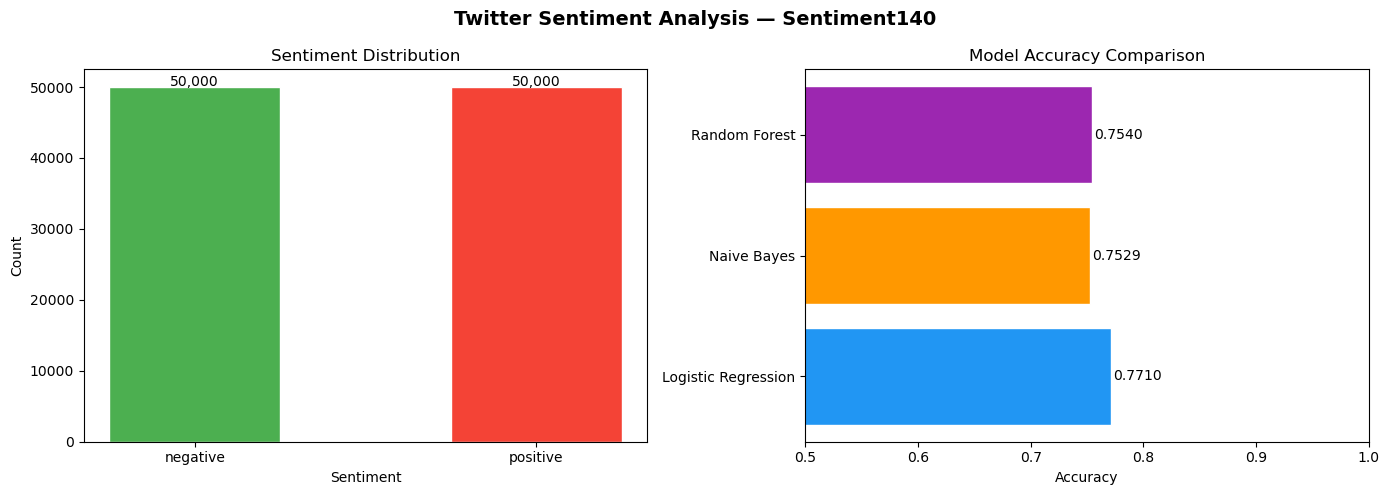

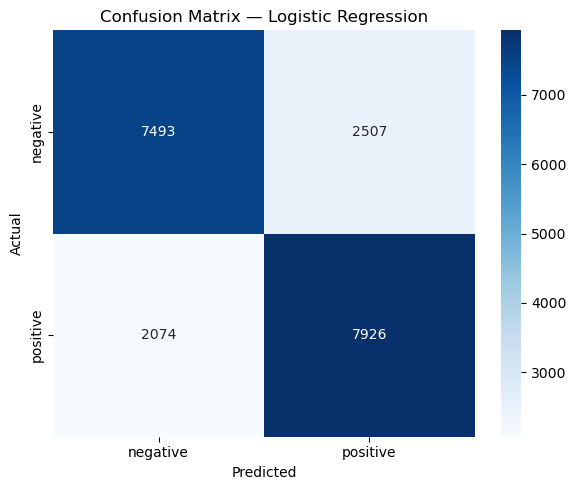


All done! Plots saved as PNG files.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Twitter Sentiment Analysis — Sentiment140", fontsize=14, fontweight='bold')

# --- 9a. Sentiment Distribution ---
counts = df['sentiment'].value_counts()
colors = ['#4CAF50', '#F44336']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title("Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha='center', fontsize=10)

# --- 9b. Model Accuracy Comparison ---
model_names = [r["Model"] for r in results]
accuracies  = [r["Accuracy"] for r in results]
bar_colors  = ['#2196F3', '#FF9800', '#9C27B0']
axes[1].barh(model_names, accuracies, color=bar_colors, edgecolor='white')
axes[1].set_xlim(0.5, 1.0)
axes[1].set_title("Model Accuracy Comparison")
axes[1].set_xlabel("Accuracy")
for i, v in enumerate(accuracies):
    axes[1].text(v + 0.002, i, f"{v:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig("sentiment_distribution_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# --- 9c. Confusion Matrix (Best Model) ---
pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, pred_best, labels=['negative', 'positive'])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = ['negative', 'positive'],
    yticklabels = ['negative', 'positive']
)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nAll done! Plots saved as PNG files.")